# Sales Analysis

- 1.	Data wrangling
- 2.	Data analysis
- 3.	Data visualization
- 4.	Report generation


In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Data Wrangling :

### a. Ensure that the data is clean and free from any missing or incorrect entries.
- 	Inspect the data manually to identify missing or incorrect information using the functions isna() and notna().



In [5]:
 # Loading the dataset 

df = pd.read_csv(r'AusApparalSales4thQrt2020.csv')
display(df[:3])

print('-'*50)

# Inspecting for nulls / NAs : 
print("No. of rows in the dataframe :",len(df))
print('\n')
# The value counts for all nulls for each column :
#'False' refers to absence of nulls since we are checking for the existence of 'nulls'

print("The value counts for all nulls for each column :\n")

for i in df.columns:
    print(df[i].isna().value_counts(),'\n')

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000


--------------------------------------------------
No. of rows in the dataframe : 7560


The value counts for all nulls for each column :

Date
False    7560
Name: count, dtype: int64 

Time
False    7560
Name: count, dtype: int64 

State
False    7560
Name: count, dtype: int64 

Group
False    7560
Name: count, dtype: int64 

Unit
False    7560
Name: count, dtype: int64 

Sales
False    7560
Name: count, dtype: int64 



In [6]:
'''
Therefore we infer that for each individual column
all rows have an absence of nulls. So all the rows contain some values.

'''

'\nTherefore we infer that for each individual column\nall rows have an absence of nulls. So all the rows contain some values.\n\n'

### . Choose a suitable data wrangling technique—either data standardization or normalization. 
### . Execute the preferred normalization method and present the resulting data. 
### . (Normalization is the preferred approach for this problem.)

In [7]:
'''

Thought of using Min-Max Normatization for columns 'Unit' and 'Sales' to scale the data b/w 0 and 1

'''

"\n\nThought of using Min-Max Normatization for columns 'Unit' and 'Sales' to scale the data b/w 0 and 1\n\n"

### The  Formula used is : 
$$
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
$$


In [8]:
# Normalizing the Unit and Sales column and scale there values between 0 and 1

Unit_scale=(df['Unit']-df['Unit'].min())/(df['Unit'].max()-df['Unit'].min())

Sales_scale=(df['Sales']-df['Sales'].min())/(df['Sales'].max()-df['Sales'].min())

# Creating a new Normalized dataframe 

normalized_df=df.copy()

# Initializing the 'Unit' and 'Sales' column with their normalized form

normalized_df['Unit'],normalized_df['Sales'] = Unit_scale,Sales_scale

display(normalized_df)

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,0.015873,0.015873
...,...,...,...,...,...,...
7555,30-Dec-2020,Afternoon,TAS,Seniors,0.190476,0.190476
7556,30-Dec-2020,Evening,TAS,Kids,0.206349,0.206349
7557,30-Dec-2020,Evening,TAS,Men,0.206349,0.206349
7558,30-Dec-2020,Evening,TAS,Women,0.142857,0.142857


### . Share your insights regarding the application of the GroupBy() function 
### . for either data chunking or merging, 
### . and offer a recommendation based on your analysis.

In [9]:
'''
For my analysis I think I will prefer grouping the data 
for 'State' and 'Group' columnn.
This will allow me to look at individuals from 
which state and which group did how many sale purchases and no of units.

'''

"\nFor my analysis I think I will prefer grouping the data \nfor 'State' and 'Group' columnn.\nThis will allow me to look at individuals from \nwhich state and which group did how many sale purchases and no of units.\n\n"

In [10]:
Grouped_data=df.groupby(['State','Group'])[['Sales','Unit']].agg('sum')

display(Grouped_data)

Sales   Unit
State Group                   
NSW   Kids     18587500   7435
      Men      19022500   7609
      Seniors  18187500   7275
      Women    19172500   7669
NT    Kids      5700000   2280
      Men       5762500   2305
      Seniors   5465000   2186
      Women     5652500   2261
QLD   Kids      8510000   3404
      Men       8392500   3357
      Seniors   8190000   3276
      Women     8325000   3330
SA    Kids     14515000   5806
      Men      14655000   5862
      Seniors  14717500   5887
      Women    14970000   5988
TAS   Kids      5775000   2310
      Men       5757500   2303
      Seniors   5650000   2260
      Women     5577500   2231
VIC   Kids     26360000  10544
      Men      26407500  10563
      Seniors  26315000  10526
      Women    26482500  10593
WA    Kids      5625000   2250
      Men       5752500   2301
      Seniors   5512500   2205
      Women     5262500   2105

# Data Analysis :

### .Perform descriptive statistical analysis on the data in the Sales and Unit columns.
### .Utilize techniques such as mean, median, mode, and standard deviation for this analysis.

In [11]:
for i in ['Sales','Unit']:
    print('Mean of',i,'=',df[i].mean())
    print('Median of',i,'=',df[i].median())
    print('Mode of',i,'=',df[i].mode())
    print('Standard Deviation of',i,'=',df[i].std())

Mean of Sales = 45013.5582010582
Median of Sales = 35000.0
Mode of Sales = 0    22500
Name: Sales, dtype: int64
Standard Deviation of Sales = 32253.506943966317
Mean of Unit = 18.00542328042328
Median of Unit = 14.0
Mode of Unit = 0    9
Name: Unit, dtype: int64
Standard Deviation of Unit = 12.901402777586458


### > Generating a Box plot for 'Sales' to further analyse the data :


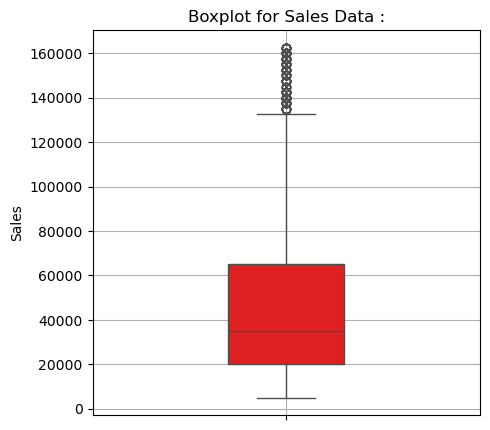

In [12]:
plt.figure(figsize=(5,5))
sns.boxplot( data =df ,
            y='Sales' ,  orient='v' , color='r' , width = 0.3)
plt.title("Boxplot for Sales Data :")
plt.grid(True)
plt.show()

### > Generating a Box plot for 'Unit' to further analyse the data :

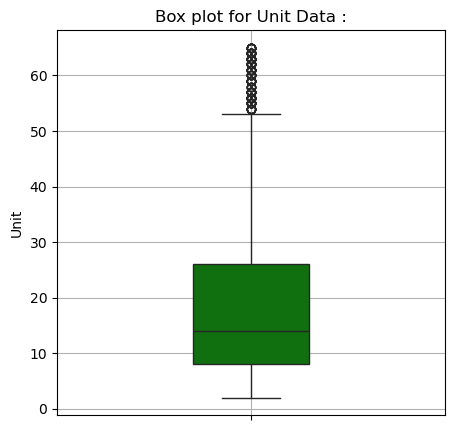

In [13]:
plt.figure(figsize=(5,5))
sns.boxplot( data =df ,
            y='Unit' ,  orient='v' , color='g' , width = 0.3)
plt.title("Box plot for Unit Data :")
plt.grid(True)
plt.show()

### .Identify the group with the highest sales and the group with the lowest sales based on the data provided.

In [14]:
# Creating total Sales data categorized via groups

Sales_Group=df.groupby('Group')['Sales'].sum()

# Print the Groups with the 'Highest' and 'Lowest' Sales

print("Group with Highest Sales :", Sales_Group.idxmax())
print("Group with Lowest Sales :", Sales_Group.idxmin())

Group with Highest Sales :  Men
Group with Lowest Sales :  Seniors


### .Generate weekly, monthly, and quarterly reports to document and present the results of the analysis conducted.

In [15]:
# Converting the 'Date' column to pandas datetime Series

df['Date']=pd.to_datetime(df['Date'])

# Presenting report 'weekly' as the total 'Sales' and total 'Units' sold 

df_week=df.resample('W',on='Date')[['Sales','Unit']].sum()
display(df_week)

# Presenting report 'monthly' as the total 'Sales' and total 'Units' sold 

df_month=df.resample('m',on='Date')[['Sales','Unit']].sum()
display(df_month)

# Presenting report 'quarterly' as the total 'Sales' and total 'Units' sold 

df_quarter=df.resample('Q', on='Date')[['Sales', 'Unit']].sum()
display(df_quarter)

,Sales,Unit
Date,,
2020-10-04,15045000,6018
2020-10-11,27002500,10801
2020-10-18,26640000,10656
2020-10-25,26815000,10726
2020-11-01,21807500,8723
2020-11-08,20865000,8346
2020-11-15,21172500,8469
2020-11-22,21112500,8445
2020-11-29,21477500,8591


C:\Users\91943\AppData\Local\Temp\ipykernel_11880\2466795645.py:12: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_month=df.resample('m',on='Date')[['Sales','Unit']].sum()


,Sales,Unit
Date,,
2020-10-31,114290000,45716
2020-11-30,90682500,36273
2020-12-31,135330000,54132


C:\Users\91943\AppData\Local\Temp\ipykernel_11880\2466795645.py:17: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_quarter=df.resample('Q', on='Date')[['Sales', 'Unit']].sum()


,Sales,Unit
Date,,
2020-12-31,340302500,136121


# Data Visualization :

### 1. State-wise Sales Analysis for Different Demographic Groups :
- This would help us visualize how each group perform across states .

In [16]:
'''
Why a Bar plot ?

Ans : To enhance understandibility and easy interpretation of the graph.
Since , the x axis is the States(Unique) and the bar itself is differentiated by 'Group'
it makes things easier to interpret.

'''

"\nWhy a Bar plot ?\n\nAns : To enhance understandibility and easy interpretation of the graph.\nSince , the x axis is the States(Unique) and the bar itself is differentiated by 'Group'\nit makes things easier to interpret.\n\n"

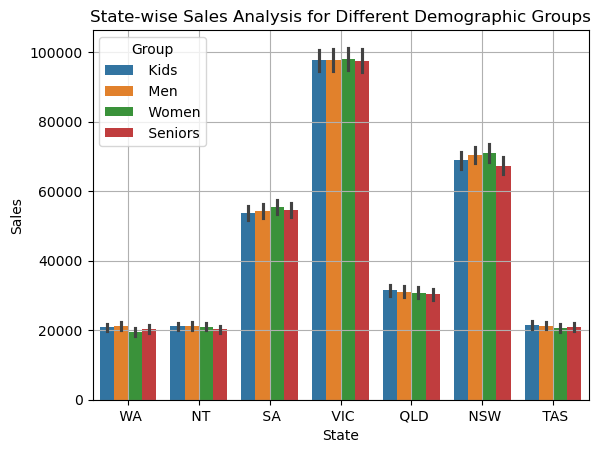

In [17]:


sns.barplot( data =df , x='State' , y='Sales' , hue='Group')
plt.title("State-wise Sales Analysis for Different Demographic Groups")
plt.grid(True)
plt.show()

### 2. State-wise Sales Analysis for Different Demographic Groups
- Taking one group at a time and analysing sales across states

In [18]:
'''
Why a barplot ?

Ans : To enhance understandibility and easier interpretation of the graph
It helps us to easily compare the Sales data for individual States.

'''

'\nWhy a barplot ?\n\nAns : To enhance understandibility and easier interpretation of the graph\nIt helps us to easily compare the Sales data for individual States.\n\n'

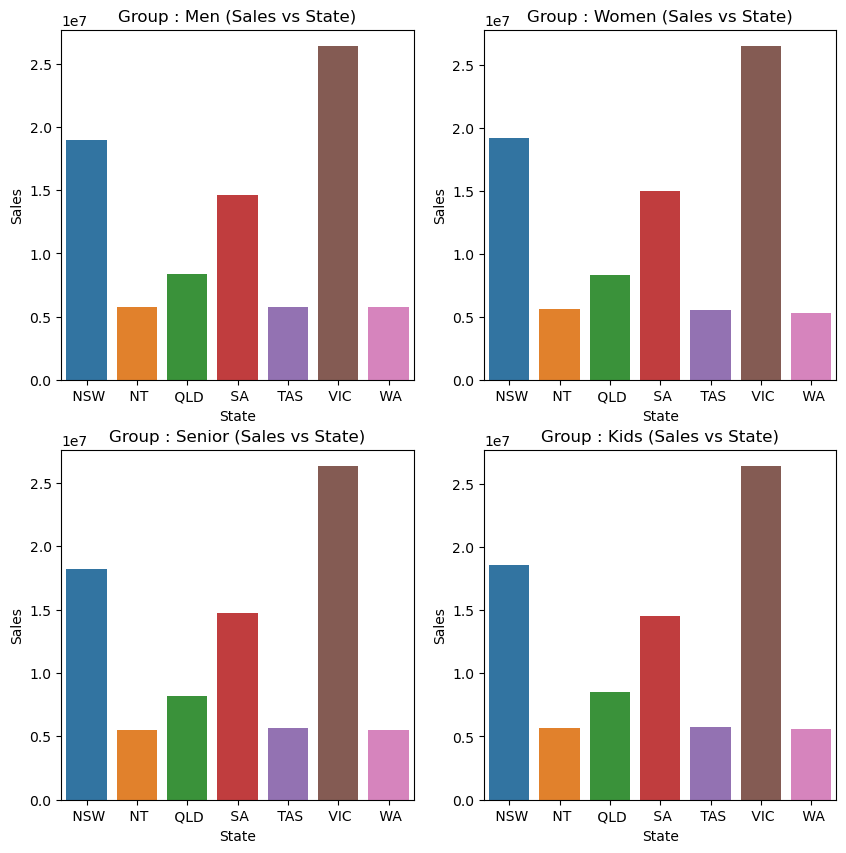

In [19]:

df['Group']=df['Group'].str.strip()

# Filtering out sales data for Men group across different states

Men_sales=df[df['Group']=='Men'].groupby('State')[['Sales']].sum()

# Filtering out sales data for Women group across different states
Women_sales=df[df['Group']=='Women'].groupby('State')[['Sales']].sum()

#Filtering out sales data for Seniors group across different states
Seniors_sales=df[df['Group']=='Seniors'].groupby('State')[['Sales']].sum()

#Filtering out sales data for Kids group across different states
Kids_sales=df[df['Group']=='Kids'].groupby('State')[['Sales']].sum()

fig=plt.figure(figsize=(10,10))
ax1=fig.add_subplot(2,2,1)
sns.barplot(data=Men_sales, x = 'State' , y= 'Sales', hue='State')
plt.title("Group : Men (Sales vs State)")
ax2=fig.add_subplot(2,2,2)
sns.barplot(data=Women_sales , x='State' , y = 'Sales' , hue='State')
plt.title("Group : Women (Sales vs State)")
ax3=fig.add_subplot(2,2,3)
sns.barplot(data=Seniors_sales , x='State' , y = 'Sales' , hue='State')
plt.title("Group : Senior (Sales vs State)")
ax4=fig.add_subplot(2,2,4)
sns.barplot(data=Kids_sales , x='State' , y = 'Sales' , hue='State')
plt.title("Group : Kids (Sales vs State)")
plt.show()



### 3. Time-of-the-Day Analysis 
- Identifying Peak and off Peak hours

,Sales
Time,
Afternoon,114007500
Evening,112087500
Morning,114207500


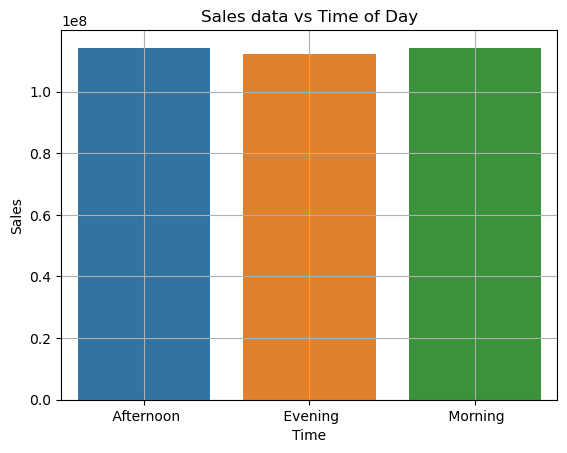

In [20]:
Time_group=df.groupby('Time')[['Sales']].sum()
display(Time_group)
sns.barplot(
    data=Time_group , 
    x=Time_group.index , y='Sales' , hue=Time_group.index)
plt.title("Sales data vs Time of Day")
plt.grid(True)
plt.show()

### Daily Sales Data :

In [21]:
'''

Why lineplot ?

Ans : Since we are to compare the Total Sales analysis
on a day-wise basis a lineplot helps us understands the trends in sales
more easily.

'''

'\n\nWhy lineplot ?\n\nAns : Since we are to compare the Total Sales analysis\non a day-wise basis a lineplot helps us understands the trends in sales\nmore easily.\n\n'

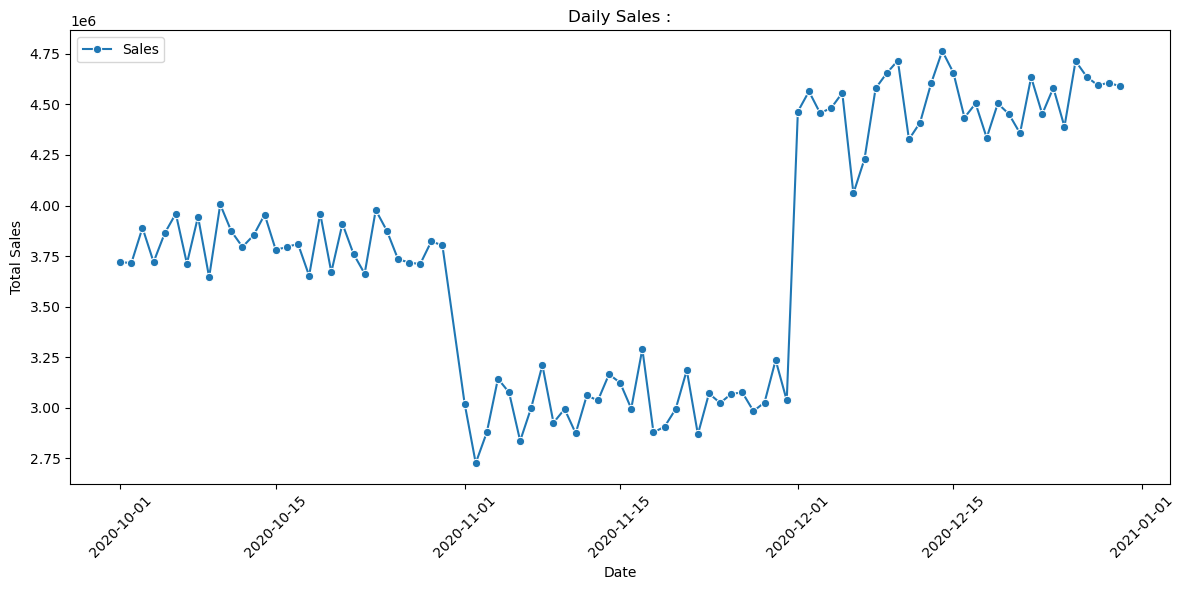

In [28]:
# Grouping the Sales data for a day and fetching total sales
daily=df.groupby('Date')[['Sales']].sum()


plt.figure(figsize=(12,6))

# Plotting Sales line 
# Using a Lineplot to properly see the variation of total sales for a day.
sns.lineplot(data=daily, x='Date', y='Sales',label='Sales' , marker='o')


plt.title("Daily Sales :")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Weekly Sales Data :


In [23]:
'''

Why a bar plot ?

Ans : Using a barplot helps us to easily differentiate 
between sales for the week.

'''

'\n\nWhy a bar plot ?\n\nAns : Using a barplot helps us to easily differentiate \nbetween sales for the week.\n\n'

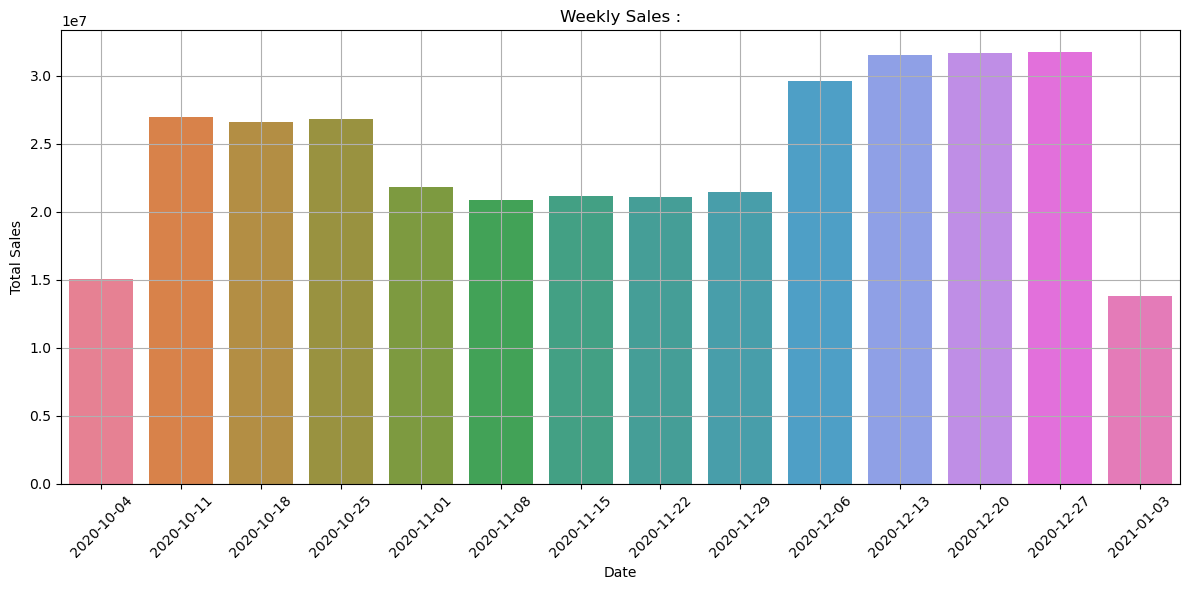

In [31]:
# Fetching the total sales Data (on weekly basis)
weekly=df.resample('W',on='Date')[['Sales']].sum()

plt.figure(figsize=(12,6))

# Plotting Sales bar
# Since there relatively fewer rows hence barplot is used for smoother visualization
sns.barplot(data=weekly, x='Date', y='Sales',hue='Date',palette='husl')


plt.title("Weekly Sales :")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly sales Data :

In [25]:
'''

Why a bar plot ?

Ans : Again since the x axis is month (Wise)
hence the total sales for individual months can be best 
compared on a barplot.

'''

'\n\nWhy a bar plot ?\n\nAns : Again since the x axis is month (Wise)\nhence the total sales for individual months can be best \ncompared on a barplot.\n\n'

C:\Users\91943\AppData\Local\Temp\ipykernel_11880\913614385.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample('M',on='Date')[['Sales']].sum()


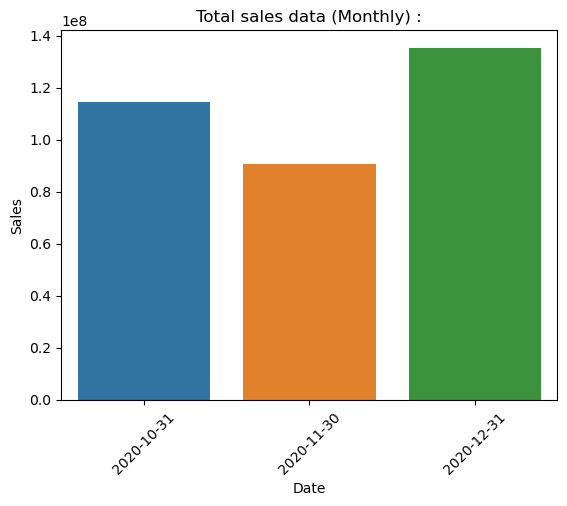

In [26]:
# Fetching the sales Data for the entire mmonth.
monthly = df.resample('M',on='Date')[['Sales']].sum()

# Again using a barplot since rows are significantly less to represent
sns.barplot(data= monthly , x='Date' , y = 'Sales',hue='Date')

plt.title("Total sales data (Monthly) :")
plt.xticks(rotation=45)
plt.show()

### Quaterly Sales Data (State wise) :

- Quaterly analysis would just give just the total sales data for the entire dataset.
- Instead we could establish a comparison between the Sales Data for each state.

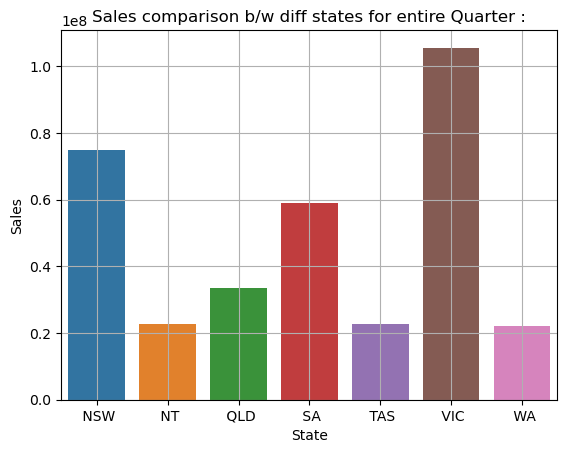

In [27]:
sns.barplot(data=df.groupby('State')[['Sales']].sum() , x='State' , y='Sales' , hue='State')
plt.title("Sales comparison b/w diff states for entire Quarter :")
plt.grid(True)
